In [ ]:
!pip install nixtla pandas numpy scikit-learn tensorflow matplotlib seaborn kaggle optuna mlforecast statsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
import kagglehub

# Download latest version
data_path = kagglehub.dataset_download('atulanandjha/temperature-readings-iot-devices')

print("Path to dataset files:", data_path)

100%|██████████| 1.02M/1.02M [00:00<00:00, 27.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/atulanandjha/temperature-readings-iot-devices/versions/1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Display settings for better readability in Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
print("Libraries imported.")

Libraries imported.


In [ ]:
df = pd.read_csv(data_path + "/IOT-temp.csv")
df.head()

,id,room_id/id,noted_date,temp,out/in
0,__export__.temp_log_196134_bd201015,Room Admin,08-12-2018 09:30,29,In
1,__export__.temp_log_196131_7bca51bc,Room Admin,08-12-2018 09:30,29,In
2,__export__.temp_log_196127_522915e3,Room Admin,08-12-2018 09:29,41,Out
3,__export__.temp_log_196128_be0919cf,Room Admin,08-12-2018 09:29,41,Out
4,__export__.temp_log_196126_d30b72fb,Room Admin,08-12-2018 09:29,31,In


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97606 entries, 0 to 97605
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          97606 non-null  object
 1   room_id/id  97606 non-null  object
 2   noted_date  97606 non-null  object
 3   temp        97606 non-null  int64 
 4   out/in      97606 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,temp
count,97606.000000
mean,35.053931
std,5.699825
min,21.000000
25%,30.000000
50%,35.000000
75%,40.000000
max,51.000000


In [ ]:
df.isnull().sum()

,0
id,0
room_id/id,0
noted_date,0
temp,0
out/in,0


In [ ]:
if df['temp'].isnull().sum() > 0:
  df['temp'].fillna(method='ffill', inplace=True)
  print(f"\nFilled missing 'temp' values using forward fill.")
  print(f"Missing 'temp' values remaining: {df['temp'].isnull().sum()}")
else:
  print("\nNo missing 'temp' values found.")


No missing 'temp' values found.


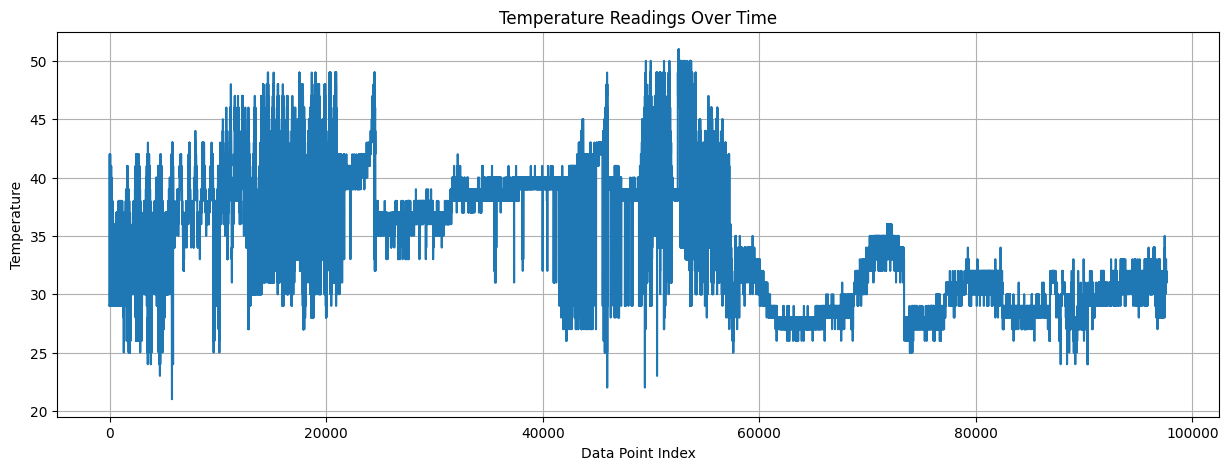

In [ ]:
plt.figure(figsize=(15, 5))
df['temp'].plot(title='Temperature Readings Over Time')
plt.ylabel('Temperature')
plt.xlabel('Data Point Index')
plt.grid(True)
plt.show()

In [ ]:
def preprocess_data(df, freq):
  df['noted_date'] = pd.to_datetime(df['noted_date'], format='%d-%m-%Y %H:%M')
  # Convert 'noted_date' to datetime objects (redundant if already done, but ensures consistency)
  df['noted_date'] = pd.to_datetime(df['noted_date'])
  # Set 'noted_date' as the index
  df = df.set_index('noted_date')
  # Sort the index chronologically
  df = df.sort_index()
  # Optional: Drop the original 'id' columns if not needed
  df = df.drop(columns=['id', 'room_id/id'], errors='ignore') # Adjust column names as needed

  # Resample the 'temp' column to a 1-minute frequency, taking the mean
  # This handles duplicate timestamps by averaging and creates a regular time series
  print("\nResampling 'temp' to 1-hour frequency (mean aggregation) to handle duplicate timestamps.")
  df = df['temp'].resample(freq).mean().to_frame()
  # Fill any gaps created by resampling (if there were missing hours) with forward fill then backward fill
  df['temp'] = df['temp'].ffill().bfill()
  return df

df = preprocess_data(df, freq='H')
print("\nConverted 'noted_date' to datetime index, sorted, and resampled.")
print(f"Index type: {df.index.dtype}")
print(f"Data ranges from {df.index.min()} to {df.index.max()}")
print("DataFrame head with datetime index:")
print(df.head())


Resampling 'temp' to 1-hour frequency (mean aggregation) to handle duplicate timestamps.

Converted 'noted_date' to datetime index, sorted, and resampled.
Index type: datetime64[ns]
Data ranges from 2018-07-28 07:00:00 to 2018-12-08 09:00:00
DataFrame head with datetime index:
                          temp
noted_date                    
2018-07-28 07:00:00  31.386364
2018-07-28 08:00:00  31.386364
2018-07-28 09:00:00  31.386364
2018-07-28 10:00:00  31.386364
2018-07-28 11:00:00  31.386364


/tmp/ipykernel_2255/2785431647.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df['temp'].resample(freq).mean().to_frame()


In [ ]:
def split_data(df):
  target_column = 'temp'
  split = 0.8
  split_index = int(len(df) * split)
  # Split the DataFrame
  train_df = df.iloc[:split_index].copy() # Use .copy() to avoid SettingWithCopyWarning
  test_df = df.iloc[split_index:].copy()
  return train_df, test_df, target_column, split_index

train_df, test_df, target_column, split_index = split_data(df)

print(f"\nSplitting data at index {split_index}:")
print(f"Training set shape: {train_df.shape}, from {train_df.index.min()} to {train_df.index.max()}")
print(f"Testing set shape: {test_df.shape}, from {test_df.index.min()} to {test_df.index.max()}")


Splitting data at index 2556:
Training set shape: (2556, 1), from 2018-07-28 07:00:00 to 2018-11-11 18:00:00
Testing set shape: (639, 1), from 2018-11-11 19:00:00 to 2018-12-08 09:00:00


In [ ]:
def scaling_data(train_df, test_df, target_column):
  scaler = MinMaxScaler()
  scaled_column_name = target_column + '_scaled'
  # Fit the scaler on the training data only and transform it
  # Need to reshape because scaler expects a 2D array [samples, features]
  train_df[scaled_column_name] = scaler.fit_transform(train_df[[target_column]])
  # Transform the test data using the same scaler
  test_df[scaled_column_name] = scaler.transform(test_df[[target_column]])
  return train_df, test_df, scaler, scaled_column_name

train_df, test_df, scaler, scaled_column_name = scaling_data(train_df, test_df, target_column)

print("\nApplied MinMaxScaler (0-1 scaling) to 'temp' column.")
print("Scaler min/max learned from training data:", scaler.data_min_, scaler.data_max_)
print("Example scaled values in training data:")
print(train_df[[target_column, scaled_column_name]].head())
print("\nExample scaled values in testing data:")
print(test_df[[target_column, scaled_column_name]].head())


Applied MinMaxScaler (0-1 scaling) to 'temp' column.
Scaler min/max learned from training data: [25.2037037] [49.]
Example scaled values in training data:
                          temp  temp_scaled
noted_date                                 
2018-07-28 07:00:00  31.386364     0.259816
2018-07-28 08:00:00  31.386364     0.259816
2018-07-28 09:00:00  31.386364     0.259816
2018-07-28 10:00:00  31.386364     0.259816
2018-07-28 11:00:00  31.386364     0.259816

Example scaled values in testing data:
                     temp  temp_scaled
noted_date                            
2018-11-11 19:00:00  41.0     0.663813
2018-11-11 20:00:00  41.0     0.663813
2018-11-11 21:00:00  41.0     0.663813
2018-11-11 22:00:00  41.0     0.663813
2018-11-11 23:00:00  41.0     0.663813


In [ ]:
def preprocess_scaled_data(train_df, test_df, target_column):
  # Use the SCALED data ('temp_scaled') as the target 'y'
  y_column_nixtla = scaled_column_name
  # Reset index to get 'noted_date' back as a column
  train_nixtla_df = train_df.reset_index()
  test_nixtla_df = test_df.reset_index() # Keep test set separate for prediction later
  # Rename columns for Nixtla
  train_nixtla_df = train_nixtla_df.rename(columns={'noted_date': 'ds', y_column_nixtla: 'y'})
  test_nixtla_df = test_nixtla_df.rename(columns={'noted_date': 'ds', y_column_nixtla: 'y'})
  # Add 'unique_id' column
  train_nixtla_df['unique_id'] = 'sensor_1'
  test_nixtla_df['unique_id'] = 'sensor_1'
  print("\nPrepared training and testing data for Nixtla format:")
  print(train_nixtla_df.head())
  # Select only the required columns for Nixtla training input
  train_nixtla_input = train_nixtla_df[['unique_id', 'ds', 'y']]
  print("\nPrepared training data for Nixtla format:")
  print(train_nixtla_input.head())
  print(f"Training input shape: {train_nixtla_input.shape}")
  return train_nixtla_input, test_nixtla_df

train_nixtla_input, test_nixtla_df = preprocess_scaled_data(train_df, test_df, target_column)


Prepared training and testing data for Nixtla format:
                   ds       temp         y unique_id
0 2018-07-28 07:00:00  31.386364  0.259816  sensor_1
1 2018-07-28 08:00:00  31.386364  0.259816  sensor_1
2 2018-07-28 09:00:00  31.386364  0.259816  sensor_1
3 2018-07-28 10:00:00  31.386364  0.259816  sensor_1
4 2018-07-28 11:00:00  31.386364  0.259816  sensor_1

Prepared training data for Nixtla format:
  unique_id                  ds         y
0  sensor_1 2018-07-28 07:00:00  0.259816
1  sensor_1 2018-07-28 08:00:00  0.259816
2  sensor_1 2018-07-28 09:00:00  0.259816
3  sensor_1 2018-07-28 10:00:00  0.259816
4  sensor_1 2018-07-28 11:00:00  0.259816
Training input shape: (2556, 3)


In [ ]:
from nixtla import NixtlaClient
# Initialize Nixtla Client
nixtla_client = NixtlaClient(api_key="nixak-3fa0587e2fe74f895833fbacb52542d7d41de01b09f84f3deb66d135c31633c6fcbf473c4aee4f46")
# If API key needed: nixtla_client = NixtlaClient(api_key='YOUR_API_KEY')

In [ ]:
# --- Define Forecast Horizon and Frequency ---
# Horizon: How many steps ahead to predict (length of our test set)
horizon = len(test_df)

In [ ]:
# Frequency: The time interval between data points
# Try to infer frequency from the data index
inferred_freq = pd.infer_freq(df.index)
if inferred_freq:
  freq = inferred_freq
  print(f"\nInferred frequency: {freq}")
else:
  # If inference fails, calculate typical difference and map to a freq string
  time_diff = (df.index[1:] - df.index[:-1]).to_series().mode()[0]
  print(f"\nTime difference between data points: {time_diff}")
  # Simple mapping (adjust if needed based on your data's actual interval)
  if time_diff == pd.Timedelta(minutes=1):
    freq = 'T'
  elif time_diff == pd.Timedelta(hours=1):
    freq = 'H'
  elif time_diff == pd.Timedelta(days=1):
    freq = 'D'
  else: freq = None # Needs manual setting
  print(f"\nCould not reliably infer frequency. Estimated difference: {time_diff}.")
  print(f"Setting freq={freq}. CHECK THIS! If None, you MUST set it manually.")
  # If freq is still None, you need to manually set it, e.g., freq = 'H'


Inferred frequency: h


In [ ]:
# --- Perform Forecast using AutoML ---
if freq is not None:
  print(f"\nAttempting forecast using AutoMLForecast (horizon={horizon}, freq='{freq}')...")
  try:
    # Pass both the target DataFrame (df) and the features DataFrame (X_df)
      fcst_df_scaled = nixtla_client.forecast(
        df=train_nixtla_input,
        h=horizon,
        freq=freq,
        level=[80, 95]
      )
      print("\nNixtla forecast with received:")
      print(fcst_df_scaled.head())
  except Exception as e:
    print(f"\nERROR during Nixtla forecast with features: {e}")
    print(">>> Please check Nixtla documentation for passing features <<<")
    fcst_df_scaled = None
else:
  print("\nSkipping Nixtla forecast with features due to missing freq or X_df.")
  fcst_df_scaled = None


Attempting forecast using AutoMLForecast (horizon=639, freq='h')...



Nixtla forecast with received:
  unique_id                  ds   TimeGPT  TimeGPT-hi-80  TimeGPT-hi-95  \
0  sensor_1 2018-11-11 19:00:00  0.667131       0.683824       0.686954   
1  sensor_1 2018-11-11 20:00:00  0.665730       0.713196       0.722096   
2  sensor_1 2018-11-11 21:00:00  0.664593       0.736215       0.749644   
3  sensor_1 2018-11-11 22:00:00  0.663756       0.775142       0.796027   
4  sensor_1 2018-11-11 23:00:00  0.663033       0.755829       0.773228   

   TimeGPT-lo-80  TimeGPT-lo-95  
0       0.650439       0.647309  
1       0.618264       0.609364  
2       0.592972       0.579543  
3       0.552369       0.531484  
4       0.570237       0.552838  


In [ ]:
# fcst_df_scaled.columns

In [ ]:
def convert_predictions(df):
  pred_col_name = None
  if fcst_df_scaled is not None:
    # The prediction column name for AutoMLForecast is typically the model name, e.g., 'AutoLightGBM'
    # Let's try to infer it dynamically by finding columns that are not unique_id or ds.

    # Filter out known non-prediction columns
    non_pred_cols = ['unique_id', 'ds']

    # Find columns that are not unique_id or ds. These should be the prediction columns.
    prediction_cols = [c for c in fcst_df_scaled.columns if c not in non_pred_cols]

    if prediction_cols:
      pred_col_name = prediction_cols[0] # Take the first one, assuming one main prediction column
      print(f"Inferred prediction column: '{pred_col_name}'")
    else:
      print("Error: Could not find a prediction column in AutoMLForecast output.")
      pred_col_name = None

  if pred_col_name:
    # Inverse transform the prediction column
    predicted_values_original_scale = scaler.inverse_transform(fcst_df_scaled[[pred_col_name]])
    # Create a clean DataFrame for predictions
    predictions_df = pd.DataFrame({
      'ds': fcst_df_scaled['ds'],
      'predicted_temp': predicted_values_original_scale.flatten() # Flatten to make it 1D
    })
    predictions_df = predictions_df.set_index('ds')
    print("\nInverse transformed predictions (original temperature scale):")
    print(predictions_df.head())
  else:
    print("\nSkipping inverse transform due to forecast error or missing prediction column.")
    predictions_df = None
  return predictions_df

predictions_df = convert_predictions(fcst_df_scaled)

Inferred prediction column: 'TimeGPT'

Inverse transformed predictions (original temperature scale):
                     predicted_temp
ds                                 
2018-11-11 19:00:00       41.078959
2018-11-11 20:00:00       41.045613
2018-11-11 21:00:00       41.018564
2018-11-11 22:00:00       40.998627
2018-11-11 23:00:00       40.981436


In [ ]:
if predictions_df is not None:
  # Use the test set created WITH features
  actual_vs_pred = test_df[[target_column]].copy() # Actual values
  actual_vs_pred = actual_vs_pred.join(predictions_df[['predicted_temp']], how='inner')

# Drop rows where prediction might be missing
initial_len = len(actual_vs_pred)
actual_vs_pred = actual_vs_pred.dropna()
print(f"Dropped {initial_len - len(actual_vs_pred)} rows with NaNs after joining.")
print("\nAligned actual vs. predicted temperatures (without features):")
print(actual_vs_pred.head())

Dropped 0 rows with NaNs after joining.

Aligned actual vs. predicted temperatures (without features):
                     temp  predicted_temp
noted_date                               
2018-11-11 19:00:00  41.0       41.078959
2018-11-11 20:00:00  41.0       41.045613
2018-11-11 21:00:00  41.0       41.018564
2018-11-11 22:00:00  41.0       40.998627
2018-11-11 23:00:00  41.0       40.981436


In [ ]:
if actual_vs_pred is not None:
  actual = actual_vs_pred["temp"]
  predicted = actual_vs_pred['predicted_temp']
  mae = mean_absolute_error(actual, predicted)
  mse = mean_squared_error(actual, predicted)
  rmse = np.sqrt(mse)
  print("\n--- Evaluation Metrics (Model with Features) ---")
  print(f"MAE: {mae:.4f}")
  print(f"MSE: {mse:.4f}")
  print(f"RMSE: {rmse:.4f}")

  # Store metrics for later comparison
  metrics_fe = {'MAE': mae, 'MSE': mse, 'RMSE': rmse}
else:
  print("\nSkipping metrics calculation due to missing predictions.")
  metrics_fe = None


--- Evaluation Metrics (Model with Features) ---
MAE: 3.2330
MSE: 18.4535
RMSE: 4.2958


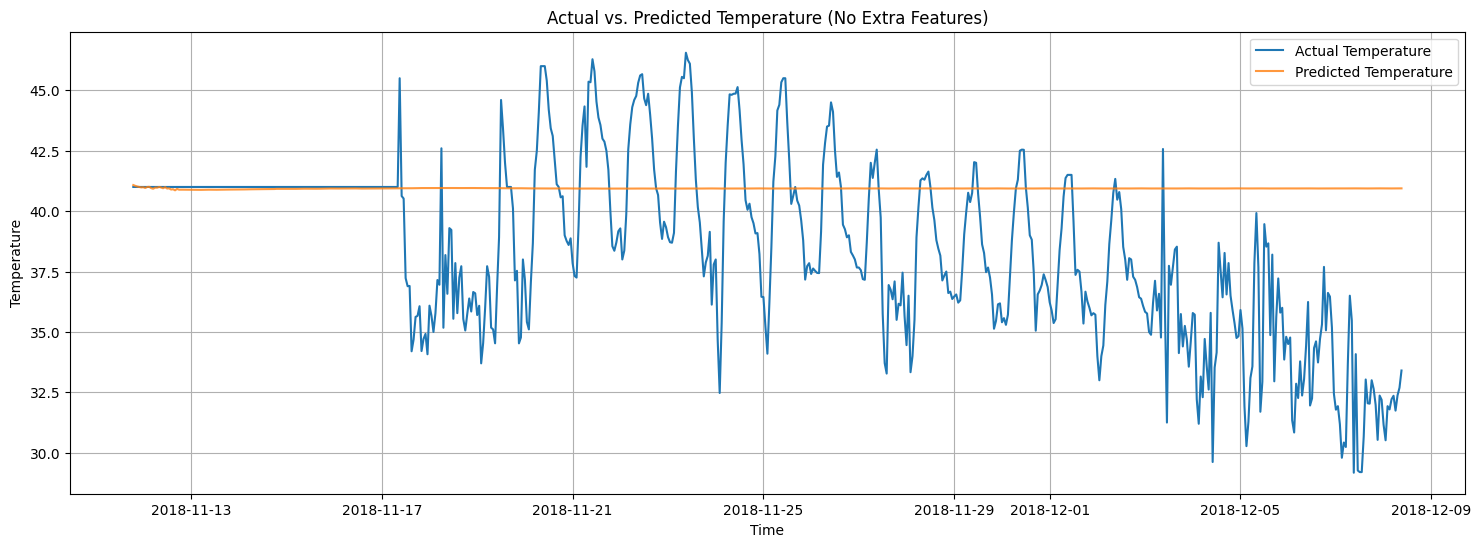

In [ ]:
if actual_vs_pred is not None:
  plt.figure(figsize=(18, 6))
  plt.plot(actual_vs_pred.index, actual_vs_pred["temp"], label='Actual Temperature')
  plt.plot(actual_vs_pred.index, actual_vs_pred['predicted_temp'],
  label='Predicted Temperature', alpha=0.8)
  plt.title('Actual vs. Predicted Temperature (No Extra Features)')
  plt.xlabel('Time')
  plt.ylabel('Temperature')
  plt.legend()
  plt.grid(True)
  plt.show()
else:
  print("\nSkipping plot due to missing predictions.")

In [ ]:
# Add features to the original DataFrame 'df'
print("\nAdding custom features...")

# Feature 1: Hour of Day (Cyclical)
df['hour'] = df.index.hour

# Feature 2: Temperature Lag (1 step back)
lag_steps = 1
df[f'temp_lag_{lag_steps}'] = df[target_column].shift(lag_steps)

df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df.head(3)

# Handle NaNs introduced by lag feature
# The first row will have NaN for the lag feature
initial_rows = len(df)
df = df.dropna()
print(f"Dropped {initial_rows - len(df)} rows with NaNs after creating lag features.")
print("DataFrame with new features:")
print("\nConverted 'noted_date' to datetime index and sorted.")
print(f"Index type: {df.index.dtype}")
print(f"Data ranges from {df.index.min()} to {df.index.max()}")
print("DataFrame head with datetime index:")
print(df.head())


Adding custom features...
Dropped 1 rows with NaNs after creating lag features.
DataFrame with new features:

Converted 'noted_date' to datetime index and sorted.
Index type: datetime64[ns]
Data ranges from 2018-07-28 08:00:00 to 2018-12-08 09:00:00
DataFrame head with datetime index:
                          temp  hour  temp_lag_1  year  month  day
noted_date                                                        
2018-07-28 08:00:00  31.386364     8   31.386364  2018      7   28
2018-07-28 09:00:00  31.386364     9   31.386364  2018      7   28
2018-07-28 10:00:00  31.386364    10   31.386364  2018      7   28
2018-07-28 11:00:00  31.386364    11   31.386364  2018      7   28
2018-07-28 12:00:00  31.386364    12   31.386364  2018      7   28


In [ ]:
print("\nRe-splitting data after adding features...")
train_df_fe, test_df_fe, _, _ = split_data(df)

print(f"Training set with features shape: {train_df_fe.shape}")
print(f"Testing set with features shape: {test_df_fe.shape}")

print("\nRe-scaling target variable ('temp') after adding features...")
train_df_fe, test_df_fe, scaler_fe, scaled_column_name_fe = scaling_data(train_df_fe, test_df_fe, target_column)

print("Example scaled values in new training data:")
print(train_df_fe[[target_column, scaled_column_name_fe, 'hour', 'temp_lag_1']].head())
print(train_df_fe.head())


Re-splitting data after adding features...
Training set with features shape: (2555, 6)
Testing set with features shape: (639, 6)

Re-scaling target variable ('temp') after adding features...
Example scaled values in new training data:
                          temp  temp_scaled  hour  temp_lag_1
noted_date                                                   
2018-07-28 08:00:00  31.386364     0.259816     8   31.386364
2018-07-28 09:00:00  31.386364     0.259816     9   31.386364
2018-07-28 10:00:00  31.386364     0.259816    10   31.386364
2018-07-28 11:00:00  31.386364     0.259816    11   31.386364
2018-07-28 12:00:00  31.386364     0.259816    12   31.386364
                          temp  hour  temp_lag_1  year  month  day  \
noted_date                                                           
2018-07-28 08:00:00  31.386364     8   31.386364  2018      7   28   
2018-07-28 09:00:00  31.386364     9   31.386364  2018      7   28   
2018-07-28 10:00:00  31.386364    10   31.386364  

In [ ]:
# Prepare 'y' data (scaled target)
y_column_nixtla_fe = scaled_column_name_fe
train_nixtla_df_fe = train_df_fe.reset_index().rename(columns={'noted_date': 'ds', y_column_nixtla_fe: 'y'})
train_nixtla_df_fe['unique_id'] = 'sensor_1'
train_nixtla_input_fe = train_nixtla_df_fe[['unique_id', 'ds', 'hour', 'temp_lag_1', 'month', 'year', 'day', 'y']]

# train_nixtla_input_fe, test_nixtla_df = preprocess_scaled_data(train_df_fe, test_df_fe, scaled_column_name_fe)

# Prepare feature DataFrame ('X_df') - must cover BOTH train and future prediction periods
# Combine train and test features, reset index for Nixtla format
features_for_nixtla = features_for_nixtla = pd.concat([train_df_fe[['hour', 'temp_lag_1', 'month', 'year', 'day']], test_df_fe[['hour', 'temp_lag_1', 'month', 'year', 'day']]])
features_for_nixtla = features_for_nixtla.reset_index().rename(columns={'noted_date': 'ds'})
features_for_nixtla['unique_id'] = 'sensor_1'

# Ensure correct columns order
X_df_nixtla = features_for_nixtla[['unique_id', 'ds', 'hour', 'temp_lag_1', 'month', 'year', 'day']][2555:]
print("\nPrepared target data ('y') for Nixtla with features:")
print(train_nixtla_input_fe.head())
print("\nPrepared features data ('X_df') for Nixtla:")
print(X_df_nixtla.head())
print(f"Shape of X_df: {X_df_nixtla.shape} (Should cover train + horizon)")



Prepared target data ('y') for Nixtla with features:
  unique_id                  ds  hour  temp_lag_1  month  year  day         y
0  sensor_1 2018-07-28 08:00:00     8   31.386364      7  2018   28  0.259816
1  sensor_1 2018-07-28 09:00:00     9   31.386364      7  2018   28  0.259816
2  sensor_1 2018-07-28 10:00:00    10   31.386364      7  2018   28  0.259816
3  sensor_1 2018-07-28 11:00:00    11   31.386364      7  2018   28  0.259816
4  sensor_1 2018-07-28 12:00:00    12   31.386364      7  2018   28  0.259816

Prepared features data ('X_df') for Nixtla:
     unique_id                  ds  hour  temp_lag_1  month  year  day
2555  sensor_1 2018-11-11 19:00:00    19        41.0     11  2018   11
2556  sensor_1 2018-11-11 20:00:00    20        41.0     11  2018   11
2557  sensor_1 2018-11-11 21:00:00    21        41.0     11  2018   11
2558  sensor_1 2018-11-11 22:00:00    22        41.0     11  2018   11
2559  sensor_1 2018-11-11 23:00:00    23        41.0     11  2018   11
Shape o

In [ ]:
print(f"\nRequesting forecast from NixtlaClient with features (horizon={horizon}, freq='{freq}')...")
# The parameter name for features might vary - check Nixtla docs!
X_df_parameter_name = 'X_df' # ASSUMPTION - VERIFY THIS in Nixtla Docs!

if freq is not None and X_df_nixtla is not None:
  print(f"\nAttempting forecast using StatsForecast (horizon={horizon}, freq='{freq}')...")

  try:
  # Pass both the target DataFrame (df) and the features DataFrame (X_df)
    fcst_df_scaled_fe = nixtla_client.forecast(
      df=train_nixtla_input_fe,
      X_df=X_df_nixtla,
      target_col='y',
      h=horizon,
      freq=freq,
      level=[80, 95]
    )
    print("\nNixtla forecast with features received:")
    print(fcst_df_scaled_fe.head())
  except Exception as e:
    print(f"\nERROR during Nixtla forecast with features: {e}")
    print(">>> Please check Nixtla documentation for passing features <<<")
    fcst_df_scaled_fe = None
else:
  print("\nSkipping Nixtla forecast with features due to missing freq or X_df.")
  fcst_df_scaled_fe = None



Requesting forecast from NixtlaClient with features (horizon=639, freq='h')...

Attempting forecast using StatsForecast (horizon=639, freq='h')...

Nixtla forecast with features received:
  unique_id                  ds   TimeGPT  TimeGPT-hi-80  TimeGPT-hi-95  \
0  sensor_1 2018-11-11 19:00:00  0.662783       0.763992       0.787541   
1  sensor_1 2018-11-11 20:00:00  0.663143       0.682101       0.687999   
2  sensor_1 2018-11-11 21:00:00  0.663403       0.719871       0.726875   
3  sensor_1 2018-11-11 22:00:00  0.660209       0.745254       0.771463   
4  sensor_1 2018-11-11 23:00:00  0.659945       0.712005       0.727951   

   TimeGPT-lo-80  TimeGPT-lo-95  
0       0.561574       0.538026  
1       0.644184       0.638287  
2       0.606935       0.599931  
3       0.575164       0.548955  
4       0.607886       0.591940  


In [ ]:
pred_col_name = None # Initialize to None to prevent NameError

if fcst_df_scaled_fe is not None:
  # The prediction column name for AutoMLForecast is typically the model name, e.g., 'AutoLightGBM'
  # Let's try to infer it dynamically by finding columns that are not unique_id or ds.

  # Filter out known non-prediction columns
  non_pred_cols = ['unique_id', 'ds']

  # Find columns that are not unique_id or ds. These should be the prediction columns.
  prediction_cols = [c for c in fcst_df_scaled_fe.columns if c not in non_pred_cols]

  if prediction_cols:
    pred_col_name = prediction_cols[0] # Take the first one, assuming one main prediction column
    print(f"Inferred prediction column: '{pred_col_name}'")
  else:
    print("Error: Could not find a prediction column in AutoMLForecast output.")
    pred_col_name = None

if pred_col_name:
  # Inverse transform the prediction column
  predicted_values_original_scale = scaler.inverse_transform(fcst_df_scaled_fe[[pred_col_name]])
  # Create a clean DataFrame for predictions
  predictions_df_fe = pd.DataFrame({
    'ds': fcst_df_scaled_fe['ds'],
    'predicted_temp': predicted_values_original_scale.flatten() # Flatten to make it 1D
  })
  predictions_df_fe = predictions_df_fe.set_index('ds')
  print("\nInverse transformed predictions (original temperature scale):")
  print(predictions_df_fe.head())
else:
  print("\nSkipping inverse transform due to forecast error or missing prediction column.")
  predictions_df_fe = None

Inferred prediction column: 'TimeGPT'

Inverse transformed predictions (original temperature scale):
                     predicted_temp
ds                                 
2018-11-11 19:00:00       40.975484
2018-11-11 20:00:00       40.984046
2018-11-11 21:00:00       40.990239
2018-11-11 22:00:00       40.914240
2018-11-11 23:00:00       40.907959


In [ ]:
if predictions_df_fe is not None:
  # Use the test set created WITH features
  actual_vs_pred_df = test_df_fe[[target_column]].copy() # Actual values
  actual_vs_pred_df = actual_vs_pred_df.join(predictions_df_fe[['predicted_temp']], how='inner')

# Drop rows where prediction might be missing
initial_len = len(actual_vs_pred_df)
actual_vs_pred_df = actual_vs_pred_df.dropna()
print(f"Dropped {initial_len - len(actual_vs_pred_df)} rows with NaNs after joining.")
print("\nAligned actual vs. predicted temperatures (with features):")
print(actual_vs_pred_df.head())

Dropped 0 rows with NaNs after joining.

Aligned actual vs. predicted temperatures (with features):
                     temp  predicted_temp
noted_date                               
2018-11-11 19:00:00  41.0       40.975484
2018-11-11 20:00:00  41.0       40.984046
2018-11-11 21:00:00  41.0       40.990239
2018-11-11 22:00:00  41.0       40.914240
2018-11-11 23:00:00  41.0       40.907959


In [ ]:
if actual_vs_pred_df is not None:
  actual = actual_vs_pred_df["temp"]
  predicted = actual_vs_pred_df['predicted_temp']
  mae = mean_absolute_error(actual, predicted)
  mse = mean_squared_error(actual, predicted)
  rmse = np.sqrt(mse)
  print("\n--- Evaluation Metrics (Model with Features) ---")
  print(f"MAE: {mae:.4f}")
  print(f"MSE: {mse:.4f}")
  print(f"RMSE: {rmse:.4f}")

  # Store metrics for later comparison
  metrics_fe = {'MAE': mae, 'MSE': mse, 'RMSE': rmse}
else:
  print("\nSkipping metrics calculation due to missing predictions.")
  metrics_fe = None


--- Evaluation Metrics (Model with Features) ---
MAE: 1.7514
MSE: 6.3368
RMSE: 2.5173


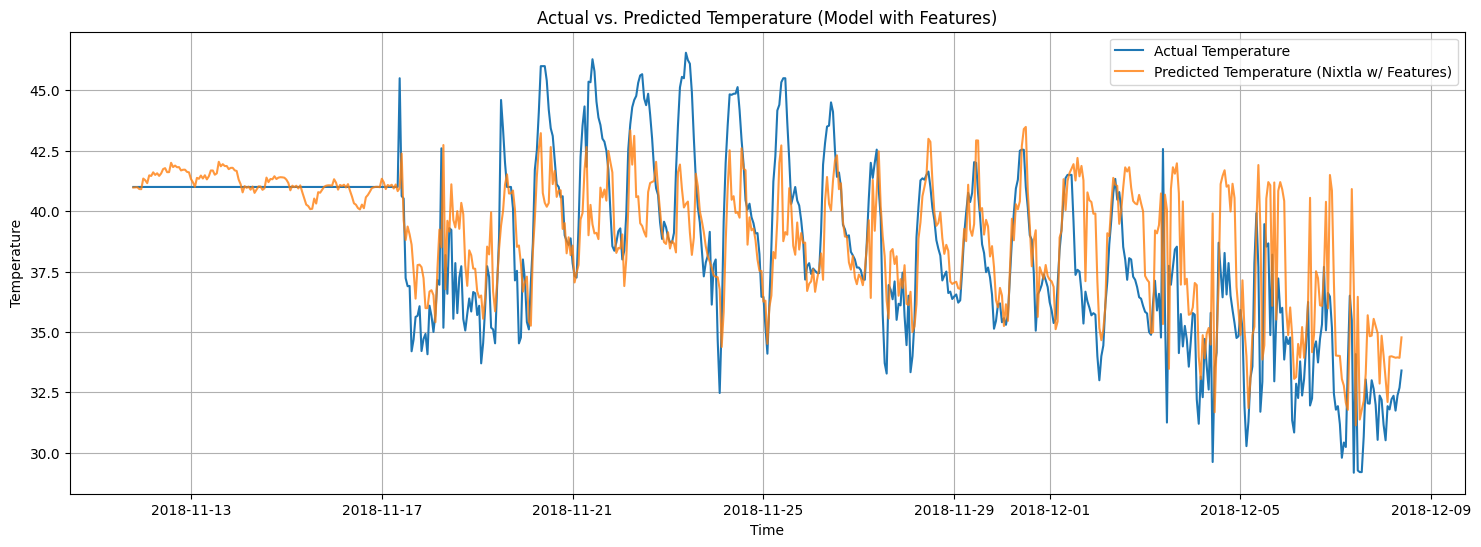

In [ ]:
if actual_vs_pred_df is not None:
  plt.figure(figsize=(18, 6))
  plt.plot(actual_vs_pred_df.index, actual_vs_pred_df[target_column], label='Actual Temperature')
  plt.plot(actual_vs_pred_df.index, actual_vs_pred_df['predicted_temp'],
  label='Predicted Temperature (Nixtla w/ Features)', alpha=0.8)
  plt.title('Actual vs. Predicted Temperature (Model with Features)')
  plt.xlabel('Time')
  plt.ylabel('Temperature')
  plt.legend()
  plt.grid(True)
  plt.show()
else:
  print("\nSkipping plot due to missing predictions.")

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
print("\n--- Rolling-Origin Cross-Validation (Conceptual Structure) ---")
# Use the full dataset prepared with features
data_for_cv = df.copy()

# Re-scale 'temp' for the whole df
scaler_cv = MinMaxScaler()
data_for_cv[scaled_column_name_fe] = scaler_cv.fit_transform(data_for_cv[[target_column]])
data_for_cv = data_for_cv.reset_index().rename(columns={'noted_date': 'ds', y_column_nixtla_fe: 'y'})
data_for_cv['unique_id'] = 'sensor_1'
cv_data_nixtla_input_fe = data_for_cv[['unique_id', 'ds', 'hour', 'temp_lag_1', 'month', 'year', 'day', 'y']]

n_splits = 3 # Number of folds
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=horizon)

all_cv_preds = {}
all_cv_actuals = {}

split_num = 0
print(f"Setting up {n_splits} splits for cross-validation.")
for train_index, test_index in tscv.split(cv_data_nixtla_input_fe):
  split_num += 1
  print(f"\n--- CV Split {split_num}/{n_splits} ---")
  cv_train_full = cv_data_nixtla_input_fe.iloc[train_index]
  cv_test_full = cv_data_nixtla_input_fe.iloc[test_index] # This is the fold to predict
  print(f" Train period: {cv_train_full['ds'].min()} to {cv_train_full['ds'].max()} ({len(cv_train_full)} points)")
  print(f" Test period: {cv_test_full['ds'].min()} to {cv_test_full['ds'].max()} ({len(cv_test_full)} points)")
  all_cv_actuals[f"split_{split_num}"] = cv_test_full['y'].values

  features_for_nixtla = features_for_nixtla = pd.concat([cv_train_full[['hour', 'ds', 'temp_lag_1', 'month', 'year', 'day']], cv_test_full[['hour', 'ds', 'temp_lag_1', 'month', 'year', 'day']]])
  features_for_nixtla['unique_id'] = 'sensor_1'
  X_df_nixtla = features_for_nixtla[['unique_id', 'ds', 'hour', 'temp_lag_1', 'month', 'year', 'day']][len(features_for_nixtla)-len(cv_test_full):]
  print("\nPrepared cv target data ('y') for Nixtla with features:")
  print(cv_train_full.head())
  print(f"Shape of cv_train_full: {cv_train_full.shape}")
  print("\nPrepared cv features data ('X_df') for Nixtla:")
  print(X_df_nixtla.head())
  print(f"Shape of X_df: {X_df_nixtla.shape} (Should cover train + horizon)")
  print(f"\nRequesting forecast from NixtlaClient with features (horizon={horizon}, freq='{freq}')...")

  if freq is not None and X_df_nixtla is not None:
    print(f"\nAttempting forecast using StatsForecast (horizon={horizon}, freq='{freq}')...")

    try:
      fcst_df = nixtla_client.forecast(
        df=cv_train_full,
        X_df=X_df_nixtla,
        target_col='y',
        h=horizon,
        freq=freq,
        level=[80, 95]
      )
      print("\nNixtla forecast with features received:")
      print(fcst_df.head())
    except Exception as e:
      print(f"\nERROR during Nixtla forecast with features: {e}")
      print(">>> Please check Nixtla documentation for passing features <<<")
      fcst_df = None
  else:
    print("\nSkipping Nixtla forecast with features due to missing freq or X_df.")
    fcst_df = None

  pred_col_name = None

  if fcst_df is not None:

    non_pred_cols = ['unique_id', 'ds']

    prediction_cols = [c for c in fcst_df.columns if c not in non_pred_cols]

    if prediction_cols:
      pred_col_name = prediction_cols[0]
      print(f"Inferred prediction column: '{pred_col_name}'")
    else:
      print("Error: Could not find a prediction column in AutoMLForecast output.")
      pred_col_name = None

  if pred_col_name:
    predicted_values_original_scale = scaler.inverse_transform(fcst_df[[pred_col_name]])
    predictions_df_fe = pd.DataFrame({
      'ds': fcst_df['ds'],
      'predicted_temp': predicted_values_original_scale.flatten()
    })
    predictions_df_fe = predictions_df_fe.set_index('ds')
    print("\nInverse transformed predictions (original temperature scale):")
    print(predictions_df_fe.head())
    all_cv_preds[f"split_{split_num}"] = predictions_df_fe
  else:
    print("\nSkipping inverse transform due to forecast error or missing prediction column.")
    predictions_df_fe = None




--- Rolling-Origin Cross-Validation (Conceptual Structure) ---
Setting up 3 splits for cross-validation.

--- CV Split 1/3 ---
 Train period: 2018-07-28 08:00:00 to 2018-09-19 12:00:00 (1277 points)
 Test period: 2018-09-19 13:00:00 to 2018-10-16 03:00:00 (639 points)

Prepared cv target data ('y') for Nixtla with features:
  unique_id                  ds  hour  temp_lag_1  month  year  day         y
0  sensor_1 2018-07-28 08:00:00     8   31.386364      7  2018   28  0.259816
1  sensor_1 2018-07-28 09:00:00     9   31.386364      7  2018   28  0.259816
2  sensor_1 2018-07-28 10:00:00    10   31.386364      7  2018   28  0.259816
3  sensor_1 2018-07-28 11:00:00    11   31.386364      7  2018   28  0.259816
4  sensor_1 2018-07-28 12:00:00    12   31.386364      7  2018   28  0.259816
Shape of cv_train_full: (1277, 8)

Prepared cv features data ('X_df') for Nixtla:
     unique_id                  ds  hour  temp_lag_1  month  year  day
1277  sensor_1 2018-09-19 13:00:00    13   41.000000


Nixtla forecast with features received:
  unique_id                  ds   TimeGPT  TimeGPT-hi-80  TimeGPT-hi-95  \
0  sensor_1 2018-09-19 13:00:00  0.668249       0.668587       0.668651   
1  sensor_1 2018-09-19 14:00:00  0.672379       0.672499       0.672521   
2  sensor_1 2018-09-19 15:00:00  0.652482       0.652732       0.652778   
3  sensor_1 2018-09-19 16:00:00  0.656113       0.656246       0.656271   
4  sensor_1 2018-09-19 17:00:00  0.661364       0.661502       0.661528   

   TimeGPT-lo-80  TimeGPT-lo-95  
0       0.667911       0.667847  
1       0.672260       0.672237  
2       0.652231       0.652185  
3       0.655980       0.655955  
4       0.661227       0.661201  
Inferred prediction column: 'TimeGPT'

Inverse transformed predictions (original temperature scale):
                     predicted_temp
ds                                 
2018-09-19 13:00:00       41.105557
2018-09-19 14:00:00       41.203840
2018-09-19 15:00:00       40.730347
2018-09-19 16:00:00    


Nixtla forecast with features received:
  unique_id                  ds   TimeGPT  TimeGPT-hi-80  TimeGPT-hi-95  \
0  sensor_1 2018-10-16 04:00:00  0.575833       0.668785       0.698526   
1  sensor_1 2018-10-16 05:00:00  0.670707       0.689527       0.695528   
2  sensor_1 2018-10-16 06:00:00  0.649727       0.674096       0.681828   
3  sensor_1 2018-10-16 07:00:00  0.666891       0.669395       0.670146   
4  sensor_1 2018-10-16 08:00:00  0.696656       0.698422       0.698934   

   TimeGPT-lo-80  TimeGPT-lo-95  
0       0.482881       0.453140  
1       0.651887       0.645885  
2       0.625359       0.617627  
3       0.664387       0.663636  
4       0.694890       0.694378  
Inferred prediction column: 'TimeGPT'

Inverse transformed predictions (original temperature scale):
                     predicted_temp
ds                                 
2018-10-16 04:00:00       38.906393
2018-10-16 05:00:00       41.164043
2018-10-16 06:00:00       40.664805
2018-10-16 07:00:00    

In [ ]:
split_metrics = {}
splits_dfs = {}
for i in range(3):
  key=f"split_{i+1}"
  print(f"\n--- Split {i+1} ---")
  preds_df = pd.DataFrame(all_cv_preds[key].copy())
  actual_values_original_scale = scaler_cv.inverse_transform(all_cv_actuals[key].reshape(-1, 1))
  actual_df = pd.DataFrame(actual_values_original_scale, columns=["temp"], index=preds_df.index)
  preds_df = preds_df.join(actual_df['temp'], how='inner')
  print(preds_df.head())
  splits_dfs[key] = preds_df

  actual = preds_df["temp"]
  predicted = preds_df['predicted_temp']
  mae = mean_absolute_error(actual, predicted)
  mse = mean_squared_error(actual, predicted)
  rmse = np.sqrt(mse)
  print("\n--- Evaluation Metrics (Model with Features) ---")
  print(f"MAE: {mae:.4f}")
  print(f"MSE: {mse:.4f}")
  print(f"RMSE: {rmse:.4f}")

  # Store metrics for later comparison
  split_metrics[key] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse}


--- Split 1 ---
                     predicted_temp       temp
ds                                            
2018-09-19 13:00:00       41.105557  37.950000
2018-09-19 14:00:00       41.203840  41.842105
2018-09-19 15:00:00       40.730347  41.555556
2018-09-19 16:00:00       40.816756  40.733333
2018-09-19 17:00:00       40.941725  41.000000

--- Evaluation Metrics (Model with Features) ---
MAE: 4.6655
MSE: 31.2378
RMSE: 5.5891

--- Split 2 ---
                     predicted_temp       temp
ds                                            
2018-10-16 04:00:00       38.906393  39.571429
2018-10-16 05:00:00       41.164043  41.178571
2018-10-16 06:00:00       40.664805  42.230769
2018-10-16 07:00:00       41.073243  43.928571
2018-10-16 08:00:00       41.781543  43.526316

--- Evaluation Metrics (Model with Features) ---
MAE: 2.6491
MSE: 10.7914
RMSE: 3.2850

--- Split 3 ---
                     predicted_temp  temp
ds                                       
2018-11-11 19:00:00       40.97

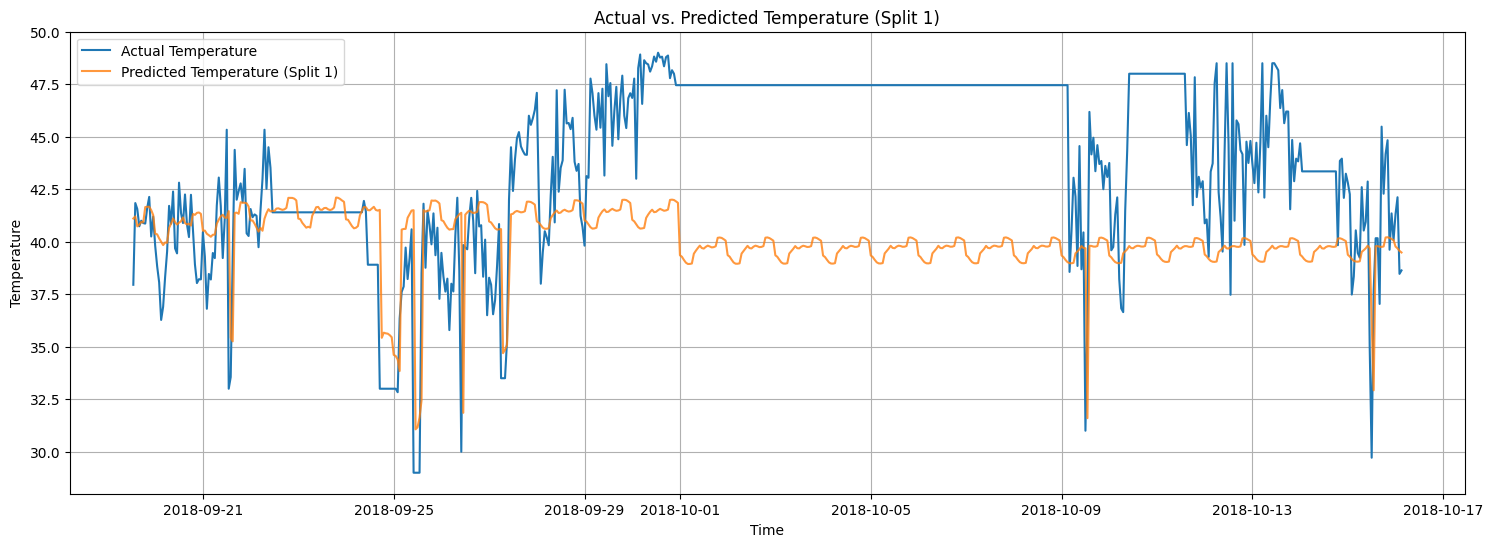

In [ ]:
plt.figure(figsize=(18, 6))
plt.plot(splits_dfs['split_1'].index, splits_dfs['split_1'][target_column], label='Actual Temperature')
plt.plot(splits_dfs['split_1'].index, splits_dfs['split_1']['predicted_temp'],
label='Predicted Temperature (Split 1)', alpha=0.8)
plt.title('Actual vs. Predicted Temperature (Split 1)')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

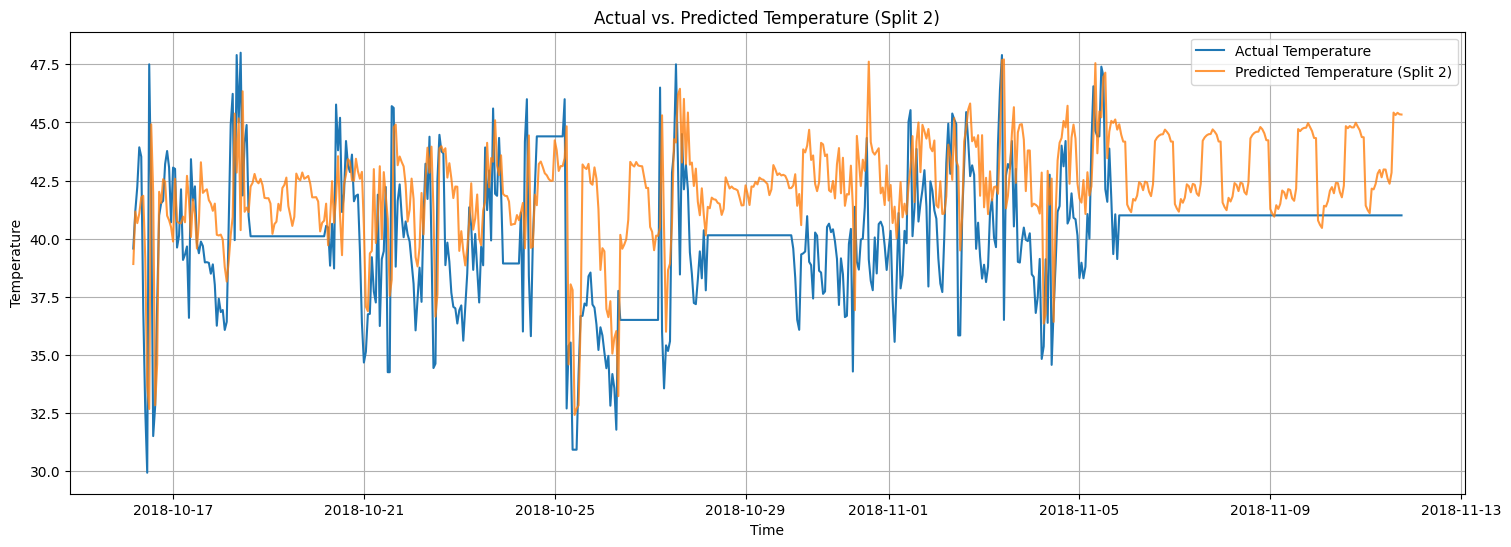

In [ ]:
plt.figure(figsize=(18, 6))
plt.plot(splits_dfs['split_2'].index, splits_dfs['split_2'][target_column], label='Actual Temperature')
plt.plot(splits_dfs['split_2'].index, splits_dfs['split_2']['predicted_temp'],
label='Predicted Temperature (Split 2)', alpha=0.8)
plt.title('Actual vs. Predicted Temperature (Split 2)')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

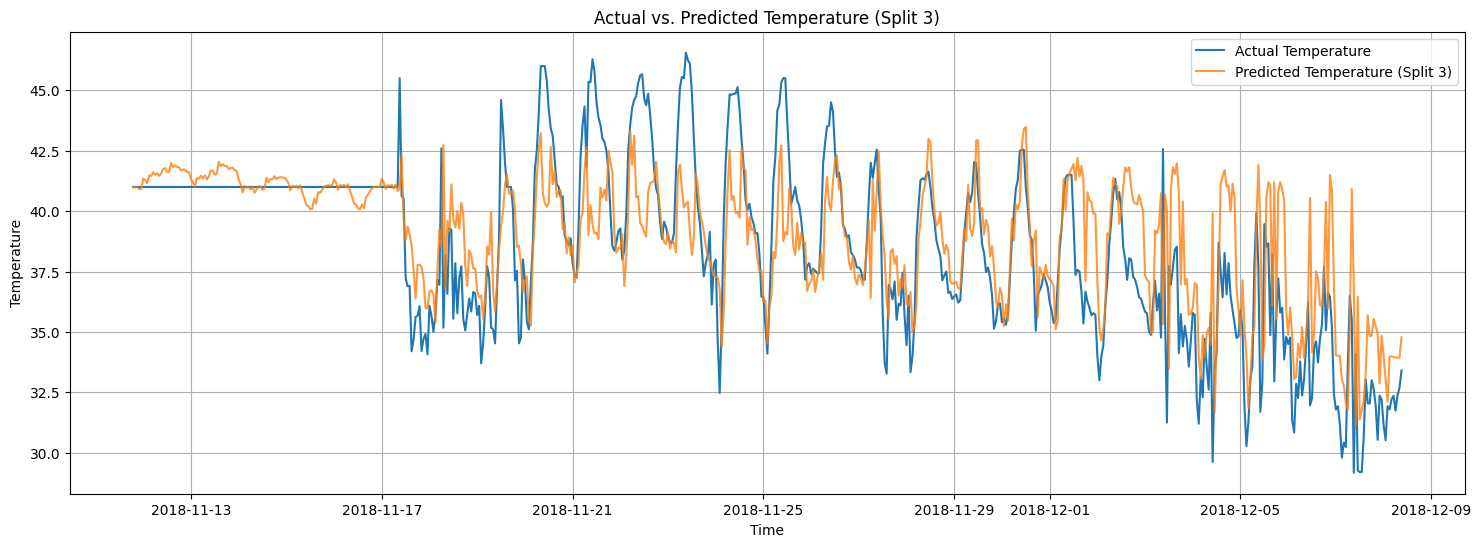

In [ ]:
plt.figure(figsize=(18, 6))
plt.plot(splits_dfs['split_3'].index, splits_dfs['split_3'][target_column], label='Actual Temperature')
plt.plot(splits_dfs['split_3'].index, splits_dfs['split_3']['predicted_temp'],
label='Predicted Temperature (Split 3)', alpha=0.8)
plt.title('Actual vs. Predicted Temperature (Split 3)')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def create_sequences(data, seq_length):
  """Creates overlapping sequences from time series data."""
  xs = []
  for i in range(len(data) - seq_length + 1): # +1 to include last possible sequence
    x = data[i:(i + seq_length)]
    xs.append(x)
  return np.array(xs)

# Define sequence length (related to patterns in your data)
sequence_length = 24 # Example: Use 24 data points per sequence
if sequence_length > len(train_df_fe):
  sequence_length = len(train_df_fe) // 4 # Adjust if train data is too short

# Use the SCALED temperature data from the training set
scaled_train_data_fe = train_df_fe[scaled_column_name_fe].values

# Create sequences
vae_train_sequences = create_sequences(scaled_train_data_fe, sequence_length)

# Reshape for VAE input: (number_of_sequences, sequence_length, num_features)
# Here, num_features is 1 because we only use scaled temp for VAE input
vae_train_sequences = vae_train_sequences.reshape((-1, sequence_length, 1))
print(f"\nCreated {len(vae_train_sequences)} sequences for VAE training.")
print(f"Shape of VAE training data: {vae_train_sequences.shape}")



Created 2532 sequences for VAE training.
Shape of VAE training data: (2532, 24, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K

# Dimensions
latent_dim = 8 # Size of the latent space (can be tuned)
input_shape = (sequence_length, 1) # Shape of one input sequence

# --- Encoder Network ---
encoder_inputs = layers.Input(shape=input_shape)

# LSTM layers are good for sequential data like temperature
x = layers.LSTM(64, activation='relu', return_sequences=True)(encoder_inputs)
x = layers.LSTM(32, activation='relu')(x)
x = layers.Dense(16, activation='relu')(x)

# VAE specific: Output mean and log-variance for the latent space distribution
z_mean = layers.Dense(latent_dim, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

# Sampling function (Reparameterization Trick)
def sampling(args):
  z_mean, z_log_var = args
  batch = tf.keras.backend.shape(z_mean)[0]
  dim = tf.keras.backend.int_shape(z_mean)[1]

  # Generate random numbers from standard normal distribution
  epsilon = tf.keras.backend.random_normal(shape=(batch, dim))

  # Combine mean, log_var, and epsilon to sample from the learned distribution
  return z_mean + tf.keras.backend.exp(0.5 * z_log_var) * epsilon

# Create the sampling layer
z = layers.Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])

# Instantiate the encoder model
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
print("\n--- Encoder Summary ---")
encoder.summary(line_length=100)

# --- Decoder Network ---
latent_inputs = layers.Input(shape=(latent_dim,))

# Dense layer to start decoding
x = layers.Dense(16, activation='relu')(latent_inputs)

# Repeat the latent vector for each step in the output sequence
x = layers.RepeatVector(sequence_length)(x)

# LSTM layers to generate the sequence
x = layers.LSTM(32, activation='relu', return_sequences=True)(x)
x = layers.LSTM(64, activation='relu', return_sequences=True)(x)

# Output layer: TimeDistributed applies a Dense layer to each time step
# Use 'sigmoid' activation because our input data was scaled 0-1
decoder_outputs = layers.TimeDistributed(layers.Dense(1, activation='sigmoid'))(x)

# Instantiate the decoder model
decoder = Model(latent_inputs, decoder_outputs, name='decoder')
print("\n--- Decoder Summary ---")
decoder.summary(line_length=100)

# --- VAE Model (Connecting Encoder and Decoder) ---
# The VAE output is the decoder's output when fed the encoder's sampled latent vector 'z'
# vae_outputs = decoder(encoder(encoder_inputs)[2]) # This line is not needed here anymore

# Custom VAE Model subclass
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, data):
        # The call method defines the forward pass when the model is used for inference
        # For training, train_step is used.
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction loss (MSE)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.math.square(data - reconstruction), axis=(1, 2)
                )
            )

            # KL Divergence Loss
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Instantiate the custom VAE model
vae_model = VAE(encoder, decoder)

# --- Compile VAE --- (No explicit loss needed if using custom train_step with metrics)
vae_model.compile(optimizer='adam', loss='mse') # Add a placeholder loss
print("\n--- VAE Summary (Combined) ---")
vae_model.build(input_shape=(None, sequence_length, 1)) # Build with dummy input shape
vae_model.summary(line_length=100)


--- Encoder Summary ---


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)    │ (None, 24, 1)           │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ lstm (LSTM)                 │ (None, 24, 64)          │         16,896 │ input_layer[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ lstm_1 (LSTM)               │ (None, 32)              │         12,416 │ lstm[0][0]              │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dense (Dense)               │ (None, 16)              │            528 │ lstm_1[0][0]            │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ z_mean (Dense)              │ (None, 8)               │            136 │ dense[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ z_log_var (Dense)           │ (None, 8)               │            136 │ dense[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ z (Lambda)                  │ (None, 8)               │              0 │ z_mean[0][0],           │
│                             │                         │                │ z_log_var[0][0]         │
└─────────────────────────────┴─────────────────────────┴────────────────┴─────────────────────────┘

 Total params: 30,112 (117.62 KB)

 Trainable params: 30,112 (117.62 KB)

...

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder (Functional)                       │ ((None, 8), (None, 8), (None,   │            30,112 │
│                                            │ 8))                             │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ decoder (Functional)                       │ (None, 24, 1)                   │            31,313 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 61,425 (239.94 KB)

 Trainable params: 61,425 (239.94 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 50
batch_size = 128

print(f"\nStarting VAE training for {epochs} epochs...")

history = vae_model.fit(
    vae_train_sequences, # Input data (same for X and y in VAE)
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    verbose=1 # Show progress bar
)

print("\nVAE training complete.")


Starting VAE training for 50 epochs...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - kl_loss: 6.3427e-04 - loss: 1.6846 - reconstruction_loss: 1.6839
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - kl_loss: 0.0031 - loss: 1.6762 - reconstruction_loss: 1.6731
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - kl_loss: 0.0086 - loss: 1.6744 - reconstruction_loss: 1.6658
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - kl_loss: 0.0232 - loss: 1.6457 - reconstruction_loss: 1.6225
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - kl_loss: 0.1688 - loss: 1.5937 - reconstruction_loss: 1.4249
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - kl_loss: 0.3022 - loss: 1.5132 - reconstruction_loss: 1.2110
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - kl_loss: 0.3596 - loss: 1.4541 - reconstruction_loss: 1.0944
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - kl_loss: 0.4234 - loss: 1.4337 - reconstruction_loss: 1.0103
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━

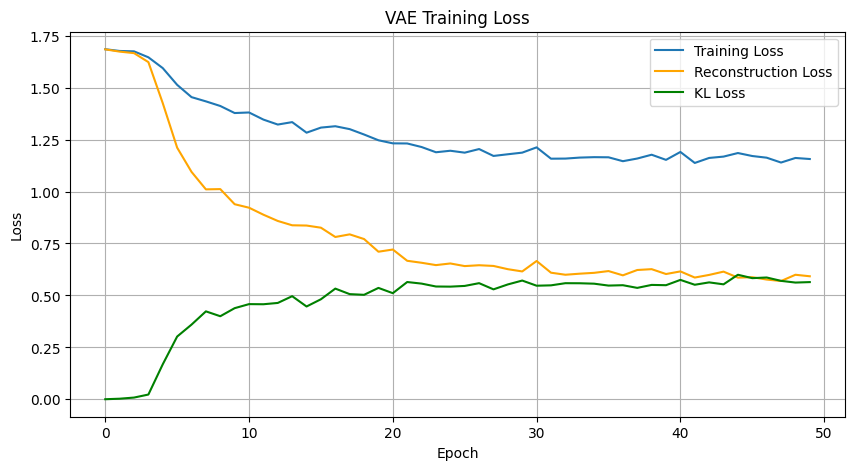

In [ ]:
# Plot training & validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['reconstruction_loss'], label='Reconstruction Loss', color="orange")
plt.plot(history.history['kl_loss'], label='KL Loss', color="green")
plt.title('VAE Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


Generating 2532 synthetic sequences...
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
Generated 60768 synthetic data points (scaled).


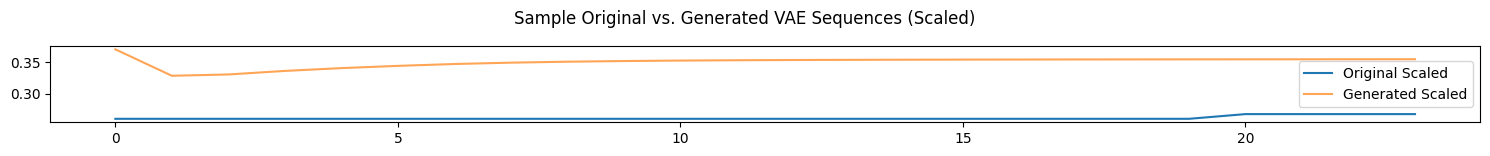

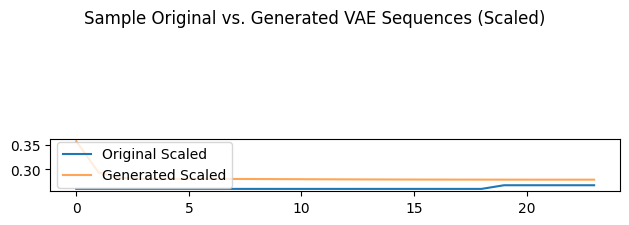

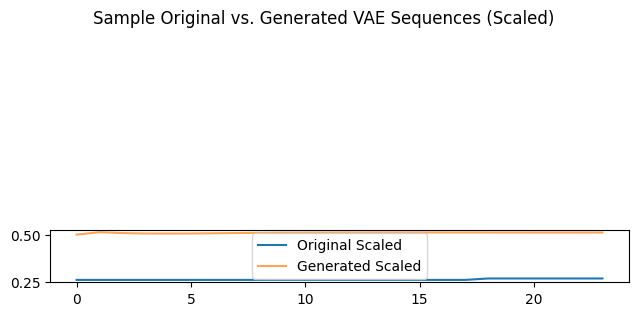

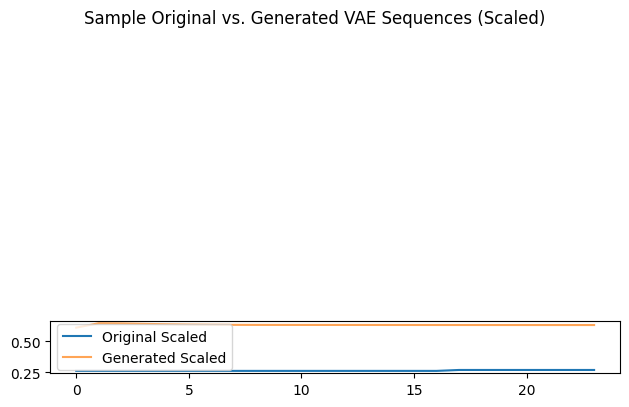

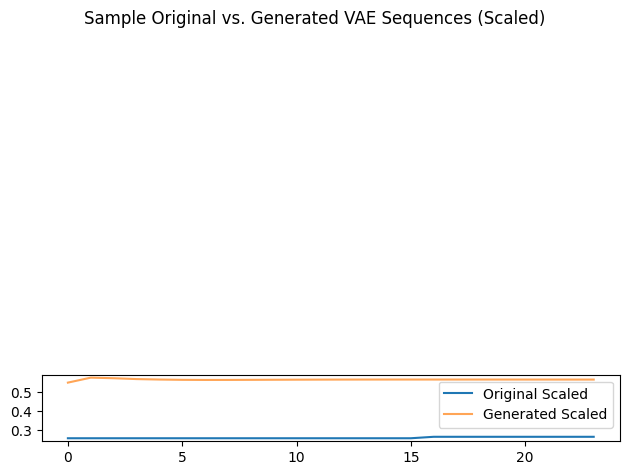

In [ ]:
# Number of synthetic sequences to generate
num_sequences_to_generate = len(vae_train_sequences) # Generate approximately the same amount of data
print(f"\nGenerating {num_sequences_to_generate} synthetic sequences...")

# Sample random points from the latent space (standard normal distribution)
random_latent_vectors = np.random.normal(size=(num_sequences_to_generate, latent_dim))

# Use the decoder to generate sequences from these random points
generated_sequences_scaled = decoder.predict(random_latent_vectors)

# Reshape generated sequences back into a flat 1D array of scaled temperature values
generated_data_scaled = generated_sequences_scaled.flatten() # Flatten into one long series
print(f"Generated {len(generated_data_scaled)} synthetic data points (scaled).")

# Plot a few generated sequences vs original sequences
num_plot = 5
plt.figure(figsize=(15, 6))
for i in range(num_plot):
  plt.subplot(num_plot, 1, i+1)
  plt.plot(vae_train_sequences[i, :, 0], label='Original Scaled')
  plt.plot(generated_sequences_scaled[i, :, 0], label='Generated Scaled', alpha=0.7)
  plt.legend()
  plt.suptitle('Sample Original vs. Generated VAE Sequences (Scaled)')
  plt.tight_layout() # Adjust layout
  plt.show()


In [ ]:
print("\nAugmenting original training data with synthetic data...")
# Original scaled training data (the 'y' column for Nixtla)
original_y_scaled = train_nixtla_input_fe[['unique_id', 'ds', 'y']].copy()

# Create a DataFrame for the generated data
num_generated = len(generated_data_scaled)
last_original_ds = original_y_scaled['ds'].max()

# Generate new timestamps for the synthetic data, continuing from the end of original train data
synthetic_ds = pd.date_range(
  start=last_original_ds + pd.Timedelta(f'1{freq}'), # Start after last train point
  periods=num_generated,
  freq=freq
) # Use the same frequency

synthetic_y_df = pd.DataFrame({
  'unique_id': 'sensor_1',
  'ds': synthetic_ds,
  'y': generated_data_scaled
})

# Concatenate original and synthetic 'y' data
augmented_nixtla_input = pd.concat([original_y_scaled, synthetic_y_df], ignore_index=True)
print(f"Original training data points: {len(original_y_scaled)}")
print(f"Synthetic data points added: {len(synthetic_y_df)}")
print(f"Augmented training data shape: {augmented_nixtla_input.shape}")
print("Augmented data ('y') head:")
print(augmented_nixtla_input.head())
print("Augmented data ('y') tail:")
print(augmented_nixtla_input.tail())


Augmenting original training data with synthetic data...
Original training data points: 2555
Synthetic data points added: 60768
Augmented training data shape: (63323, 3)
Augmented data ('y') head:
  unique_id                  ds         y
0  sensor_1 2018-07-28 08:00:00  0.259816
1  sensor_1 2018-07-28 09:00:00  0.259816
2  sensor_1 2018-07-28 10:00:00  0.259816
3  sensor_1 2018-07-28 11:00:00  0.259816
4  sensor_1 2018-07-28 12:00:00  0.259816
Augmented data ('y') tail:
      unique_id                  ds         y
63318  sensor_1 2025-10-17 14:00:00  0.249788
63319  sensor_1 2025-10-17 15:00:00  0.249783
63320  sensor_1 2025-10-17 16:00:00  0.249780
63321  sensor_1 2025-10-17 17:00:00  0.249778
63322  sensor_1 2025-10-17 18:00:00  0.249777


In [ ]:
if freq is not None and augmented_nixtla_input is not None:
  try:
    # Train on augmented 'y' data, without X_df this time
    fcst_df_scaled_aug = nixtla_client.forecast(
      df=augmented_nixtla_input,
      h=horizon,
      freq=freq,
      level=[80, 95]
    )
    print("\nNixtla forecast (trained on augmented data) received:")
    print(fcst_df_scaled_aug.head())
  except Exception as e:
    print(f"\nERROR during Nixtla forecast on augmented data: {e}")
    fcst_df_scaled_aug = None
else:
  print("\nSkipping Nixtla forecast on augmented data due to missing freq or input.")
  fcst_df_scaled_aug = None


Nixtla forecast (trained on augmented data) received:
  unique_id                  ds   TimeGPT  TimeGPT-hi-80  TimeGPT-hi-95  \
0  sensor_1 2025-10-17 19:00:00  0.247544       0.248625       0.248827   
1  sensor_1 2025-10-17 20:00:00  0.247219       0.248054       0.248210   
2  sensor_1 2025-10-17 21:00:00  0.249991       0.253059       0.253635   
3  sensor_1 2025-10-17 22:00:00  0.254386       0.259806       0.260822   
4  sensor_1 2025-10-17 23:00:00  0.257522       0.266328       0.267980   

   TimeGPT-lo-80  TimeGPT-lo-95  
0       0.246463       0.246260  
1       0.246385       0.246228  
2       0.246923       0.246348  
3       0.248966       0.247950  
4       0.248716       0.247064  



Inverse transformed predictions (trained on augmented data):
                     predicted_temp
ds                                 
2025-10-17 19:00:00       31.094325
2025-10-17 20:00:00       31.086604
2025-10-17 21:00:00       31.152569
2025-10-17 22:00:00       31.257154
2025-10-17 23:00:00       31.331774

Actual Temps:
                     temp
noted_date               
2018-11-11 19:00:00  41.0
2018-11-11 20:00:00  41.0
2018-11-11 21:00:00  41.0
2018-11-11 22:00:00  41.0
2018-11-11 23:00:00  41.0

--- Evaluation Metrics (Model Trained on Augmented Data) ---
MAE (Augmented): 6.4618
MSE (Augmented): 53.0503
RMSE (Augmented): 7.2836

--- Metrics Comparison ---
Model with Features (No Augmentation): MAE=1.7514, RMSE=2.5173
Model Trained on Augmented Data: MAE=6.4618, RMSE=7.2836
Change due to augmentation: MAE +4.7104, RMSE +4.7663
>>> Augmentation worsened or did not improve MAE


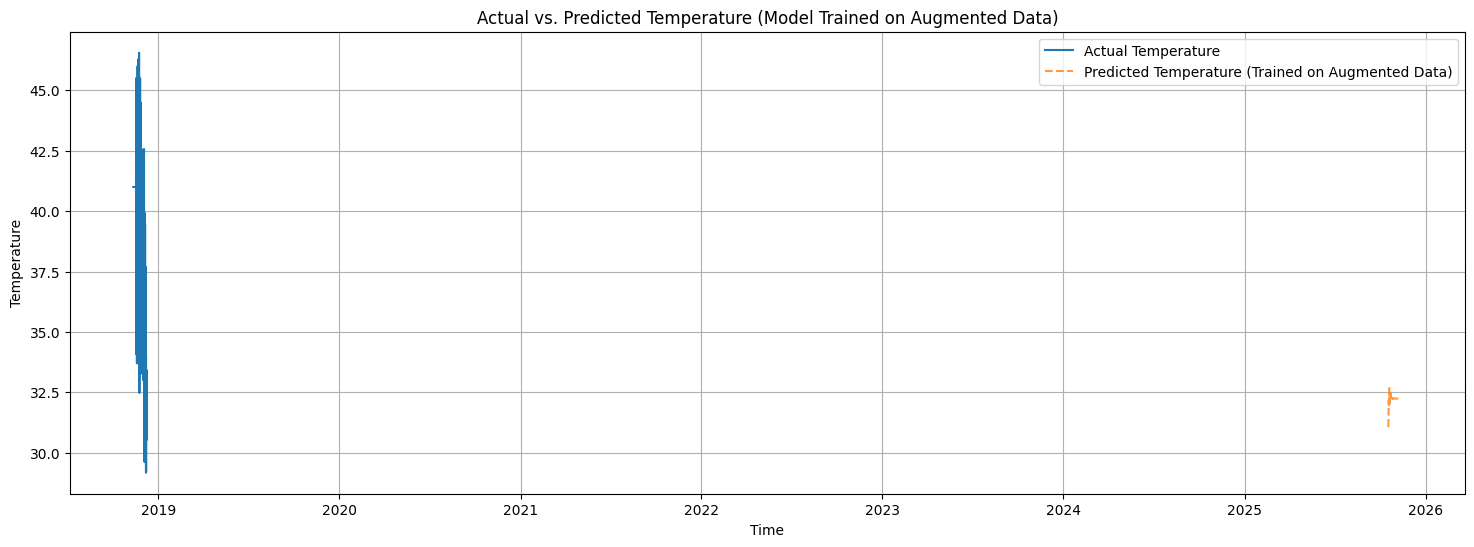

In [ ]:
# Inverse transform augmented model's predictions
pred_col_name_aug = None # Initialize
if fcst_df_scaled_aug is not None:
  pred_col_name_aug = 'TimeGPT' # Adjust if needed
if pred_col_name_aug not in fcst_df_scaled_aug.columns:
  potential_cols_aug = [c for c in fcst_df_scaled_aug.columns if c not in ['unique_id', 'ds'] and '-lo-' not in c and '-hi-' not in c]
  if potential_cols_aug:
    pred_col_name_aug = potential_cols_aug[0]
    print(f"Warning: Using prediction column '{pred_col_name_aug}'.")
  else:
    print("Error: Could not find prediction column.")
    pred_col_name_aug = None
if pred_col_name_aug:
  # Use the scaler fitted on the data WITH features ('scaler_fe')
  predicted_values_aug = scaler_fe.inverse_transform(fcst_df_scaled_aug[[pred_col_name_aug]])
  predictions_df_aug = pd.DataFrame({
    'ds': fcst_df_scaled_aug['ds'],
    'predicted_temp': predicted_values_aug.flatten()
  }).set_index('ds')
  print("\nInverse transformed predictions (trained on augmented data):")
  print(predictions_df_aug.head())

# Align with actual test data
actual_vs_pred_aug_df = None
if predictions_df_aug is not None:
  actual_vs_pred_aug_df = test_df_fe[[target_column]].copy()
  actual_vs_pred_aug_df = actual_vs_pred_aug_df.dropna()
  print("\nActual Temps:")
  print(actual_vs_pred_aug_df.head())

# Calculate metrics for augmented model
metrics_aug = None
if actual_vs_pred_aug_df is not None and not actual_vs_pred_aug_df.empty:
  actual_aug = actual_vs_pred_aug_df[target_column]
  predicted_aug = predictions_df_aug['predicted_temp']
  mae_aug = mean_absolute_error(actual_aug, predicted_aug)
  mse_aug = mean_squared_error(actual_aug, predicted_aug)
  rmse_aug = np.sqrt(mse_aug)
  print("\n--- Evaluation Metrics (Model Trained on Augmented Data) ---")
  print(f"MAE (Augmented): {mae_aug:.4f}")
  print(f"MSE (Augmented): {mse_aug:.4f}")
  print(f"RMSE (Augmented): {rmse_aug:.4f}")
  metrics_aug = {'MAE': mae_aug, 'MSE': mse_aug, 'RMSE': rmse_aug}
else:
  print("\nSkipping metrics for augmented model due to missing predictions or alignment issues.")
# --- Compare Metrics ---
print("\n--- Metrics Comparison ---")

if metrics_fe is not None:
  print(f"Model with Features (No Augmentation): MAE={metrics_fe['MAE']:.4f}, RMSE={metrics_fe['RMSE']:.4f}")
else:
  print("Metrics for model with features (no augmentation) are unavailable.")

if metrics_aug is not None:
  print(f"Model Trained on Augmented Data: MAE={metrics_aug['MAE']:.4f}, RMSE={metrics_aug['RMSE']:.4f}")

  if metrics_fe:
    mae_diff = metrics_aug['MAE'] - metrics_fe['MAE']
    rmse_diff = metrics_aug['RMSE'] - metrics_fe['RMSE']
    print(f"Change due to augmentation: MAE {mae_diff:+.4f}, RMSE {rmse_diff:+.4f}")
    if mae_diff < 0:
      print(">>> Augmentation IMPROVED MAE (Lower is better)")
    else:
      print(">>> Augmentation worsened or did not improve MAE")
else:
  print("Metrics for augmented model are unavailable.")

# Plot augmented model results
if actual_vs_pred_aug_df is not None:
  plt.figure(figsize=(18, 6))
  plt.plot(actual_vs_pred_aug_df.index, actual_vs_pred_aug_df[target_column],
  label='Actual Temperature')
  plt.plot(predictions_df_aug.index, predictions_df_aug['predicted_temp'],
  label='Predicted Temperature (Trained on Augmented Data)', alpha=0.8, linestyle='--')
  plt.title('Actual vs. Predicted Temperature (Model Trained on Augmented Data)')
  plt.xlabel('Time')
  plt.ylabel('Temperature')
  plt.legend()
  plt.grid(True)
  plt.show()